# HW07

Кластеризация на трёх синтетических датасетах: KMeans, DBSCAN и AgglomerativeClustering, внутренние метрики качества, PCA-визуализация и проверка устойчивости.

In [2]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

from hw07_pipeline import DATASETS, build_summary_tables, load_dataset, run_homework

result = run_homework(force=False)
metrics_df, best_df = build_summary_tables(result)
metrics_df.head()

,dataset,algorithm,params,silhouette,davies_bouldin,calinski_harabasz,noise_share
0,Dataset A,KMeans,"{""k"": 2, ""n_init"": 20, ""random_state"": 42}",0.521640,0.685330,11786.954623,0.0
1,Dataset A,KMeans,"{""k"": 3, ""n_init"": 20, ""random_state"": 42}",0.396758,0.964604,10446.638111,0.0
2,Dataset A,KMeans,"{""k"": 4, ""n_init"": 20, ""random_state"": 42}",0.383301,1.160349,9427.499744,0.0
3,Dataset A,KMeans,"{""k"": 5, ""n_init"": 20, ""random_state"": 42}",0.354801,1.273719,8301.205994,0.0
4,Dataset A,KMeans,"{""k"": 6, ""n_init"": 20, ""random_state"": 42}",0.348097,1.150925,7479.989972,0.0


## Первичный анализ данных

In [3]:
for dataset_key, config in DATASETS.items():
    df = load_dataset(dataset_key)
    print(f"\n=== {config['title']} / {config['local_name']} ===")
    display(df.head())
    display(df.describe(include='all').transpose().head(12))
    print(df.info())
    print('missing share:', df.isna().mean().round(4).to_dict())


=== Dataset A / S07-hw-dataset-01.csv ===


,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
0,0,-0.536647,-69.812900,-0.002657,71.743147,-11.396498,-12.291287,-6.836847,-0.504094
1,1,15.230731,52.727216,-1.273634,-104.123302,11.589643,34.316967,-49.468873,0.390356
2,2,18.542693,77.317150,-1.321686,-111.946636,10.254346,25.892951,44.595250,0.325893
3,3,-12.538905,-41.709458,0.146474,16.322124,1.391137,2.014316,-39.930582,0.139297
4,4,-6.903056,61.833444,-0.022466,-42.631335,3.107154,-5.471054,7.001149,0.131213


,count,mean,std,min,25%,50%,75%,max
sample_id,12000.0,5999.500000,3464.245950,0.000000,2999.750000,5999.500000,8999.250000,11999.000000
f01,12000.0,-2.424716,11.014315,-19.912573,-9.472623,-6.869404,0.523841,24.403381
f02,12000.0,19.107804,60.790338,-92.892652,-40.282955,54.069335,70.280739,112.229523
f03,12000.0,-0.222063,0.500630,-1.590979,-0.125145,-0.031753,0.054980,0.512277
f04,12000.0,-8.284501,59.269838,-134.303679,-48.345007,16.211728,28.067178,75.088604
f05,12000.0,-0.190717,7.026435,-11.869169,-5.132473,0.444730,3.942368,13.717091
f06,12000.0,0.962972,14.794713,-20.521164,-8.807706,-6.134169,2.334426,41.452857
f07,12000.0,0.033724,59.541782,-215.098834,-39.900520,-0.578494,39.719821,213.381767
f08,12000.0,0.007638,0.607053,-2.633469,-0.401483,0.005306,0.410132,2.490745


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  12000 non-null  int64  
 1   f01        12000 non-null  float64
 2   f02        12000 non-null  float64
 3   f03        12000 non-null  float64
 4   f04        12000 non-null  float64
 5   f05        12000 non-null  float64
 6   f06        12000 non-null  float64
 7   f07        12000 non-null  float64
 8   f08        12000 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 843.9 KB
None
missing share: {'sample_id': 0.0, 'f01': 0.0, 'f02': 0.0, 'f03': 0.0, 'f04': 0.0, 'f05': 0.0, 'f06': 0.0, 'f07': 0.0, 'f08': 0.0}

=== Dataset B / S07-hw-dataset-02.csv ===


,sample_id,x1,x2,z_noise
0,0,0.098849,-1.846034,21.288122
1,1,-1.024516,1.829616,6.072952
2,2,-1.094178,-0.158545,-18.938342
3,3,-1.612808,-1.565844,-11.629462
4,4,1.659901,-2.133292,1.895472


,count,mean,std,min,25%,50%,75%,max
sample_id,8000.0,3999.500000,2309.545410,0.000000,1999.750000,3999.500000,5999.250000,7999.000000
x1,8000.0,0.478867,0.955138,-2.487352,-0.116516,0.490658,1.085263,2.987555
x2,8000.0,0.241112,0.663195,-2.499237,-0.242357,0.241092,0.726526,2.995553
z_noise,8000.0,0.110454,8.097716,-34.056074,-5.392210,0.132470,5.655605,29.460076


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  8000 non-null   int64  
 1   x1         8000 non-null   float64
 2   x2         8000 non-null   float64
 3   z_noise    8000 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 250.1 KB
None
missing share: {'sample_id': 0.0, 'x1': 0.0, 'x2': 0.0, 'z_noise': 0.0}

=== Dataset C / S07-hw-dataset-04.csv ===


,sample_id,cat_a,cat_b,n01,n02,n03,n04,n05,n06,n07,...,n21,n22,n23,n24,n25,n26,n27,n28,n29,n30
0,0,B,X,-4.827501,-24.507466,-7.852963,0.771781,28.297884,-4.493911,-42.769449,...,24.597176,-26.354320,4.543397,-19.549036,-3.051332,-5.538587,-3.084457,5.499629,-6.128896,3.132067
1,1,F,V,51.302500,NaN,5.534737,51.305464,-8.027553,28.297548,NaN,...,-18.216260,8.527932,17.202115,-30.452260,0.855326,1.199066,3.597555,-2.239703,2.932710,0.473145
2,2,A,W,-4.820828,-2.625385,27.891578,1.523041,-5.776687,-16.298523,2.462937,...,-48.260775,9.313232,12.323411,55.081325,-3.945606,-0.280540,-0.130583,-7.353205,-2.942836,1.460477
3,3,B,X,-2.627573,-25.063639,-9.450011,-8.344669,22.371118,-11.525848,-43.762607,...,24.700663,-25.466915,-3.398665,-18.174541,0.438229,3.152556,3.859283,-2.678769,-2.213923,-4.724639
4,4,C,Y,-11.415710,-8.692169,48.636163,14.661826,-39.634618,10.769075,40.187536,...,-79.710383,-13.694253,41.575892,-9.498640,1.529608,-1.641347,3.500090,3.111257,1.475232,-1.321676


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
sample_id,10000.0,NaN,NaN,NaN,4999.5,2886.89568,0.0,2499.75,4999.5,7499.25,9999.0
cat_a,10000,6,E,1692,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cat_b,10000,6,V,1682,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n01,9826.0,NaN,NaN,NaN,17.348435,22.578551,-22.43709,-3.975438,22.042807,37.535647,65.446912
n02,9811.0,NaN,NaN,NaN,-2.05762,19.04341,-37.546998,-14.200552,-6.532183,2.092197,43.326647
n03,9801.0,NaN,NaN,NaN,7.908302,25.637807,-38.136412,-8.591513,0.3504,30.72563,60.185729
n04,9808.0,NaN,NaN,NaN,14.269157,18.815319,-23.374316,-1.223379,10.069142,29.807101,65.094588
n05,9799.0,NaN,NaN,NaN,0.90059,20.981294,-45.91407,-5.086756,2.413111,18.398883,42.527554
n06,9817.0,NaN,NaN,NaN,5.832787,13.221646,-20.650038,-4.532057,7.391953,13.033076,39.933274
n07,9796.0,NaN,NaN,NaN,-0.840875,26.583849,-60.297304,-13.55472,-2.429024,16.095731,48.591236


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 33 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  10000 non-null  int64  
 1   cat_a      10000 non-null  object 
 2   cat_b      10000 non-null  object 
 3   n01        9826 non-null   float64
 4   n02        9811 non-null   float64
 5   n03        9801 non-null   float64
 6   n04        9808 non-null   float64
 7   n05        9799 non-null   float64
 8   n06        9817 non-null   float64
 9   n07        9796 non-null   float64
 10  n08        9806 non-null   float64
 11  n09        9805 non-null   float64
 12  n10        9811 non-null   float64
 13  n11        9796 non-null   float64
 14  n12        9798 non-null   float64
 15  n13        9803 non-null   float64
 16  n14        9802 non-null   float64
 17  n15        9814 non-null   float64
 18  n16        9809 non-null   float64
 19  n17        9788 non-null   float64
 20  n18    

## Сводка метрик по всем конфигурациям

In [4]:
metrics_df

,dataset,algorithm,params,silhouette,davies_bouldin,calinski_harabasz,noise_share
0,Dataset A,KMeans,"{""k"": 2, ""n_init"": 20, ""random_state"": 42}",0.521640,0.685330,11786.954623,0.0
1,Dataset A,KMeans,"{""k"": 3, ""n_init"": 20, ""random_state"": 42}",0.396758,0.964604,10446.638111,0.0
2,Dataset A,KMeans,"{""k"": 4, ""n_init"": 20, ""random_state"": 42}",0.383301,1.160349,9427.499744,0.0
3,Dataset A,KMeans,"{""k"": 5, ""n_init"": 20, ""random_state"": 42}",0.354801,1.273719,8301.205994,0.0
4,Dataset A,KMeans,"{""k"": 6, ""n_init"": 20, ""random_state"": 42}",0.348097,1.150925,7479.989972,0.0
...,...,...,...,...,...,...,...
77,Dataset C,Agglomerative,"{""k"": 3, ""linkage"": ""average""}",0.306091,1.434369,3303.379822,0.0
78,Dataset C,Agglomerative,"{""k"": 4, ""linkage"": ""average""}",0.372104,1.119144,3739.606741,0.0
79,Dataset C,Agglomerative,"{""k"": 5, ""linkage"": ""average""}",0.447369,0.975904,5087.688517,0.0
80,Dataset C,Agglomerative,"{""k"": 6, ""linkage"": ""average""}",0.423797,0.900534,4071.625779,0.0


## Лучшие конфигурации

In [5]:
best_df

,dataset,best_algorithm,params,silhouette,davies_bouldin,calinski_harabasz,noise_share,labels_file
0,Dataset A,KMeans,"{""k"": 2, ""n_init"": 20, ""random_state"": 42}",0.521640,0.685330,11786.954623,0.0,labels_hw07_dataset_a.csv
1,Dataset B,KMeans,"{""k"": 2, ""n_init"": 20, ""random_state"": 42}",0.306861,1.323472,3573.393333,0.0,labels_hw07_dataset_b.csv
2,Dataset C,KMeans,"{""k"": 5, ""n_init"": 20, ""random_state"": 42}",0.447369,0.975904,5087.688517,0.0,labels_hw07_dataset_c.csv


## Устойчивость KMeans на Dataset A

In [6]:
pd.DataFrame([result['stability']])

,seeds,mean_pairwise_ari,min_pairwise_ari,max_pairwise_ari,silhouette_mean,silhouette_std
0,"[11, 19, 27, 35, 43]",1.0,1.0,1.0,0.52164,0.0


## Визуализации лучших решений


=== Dataset A ===
Best config: KMeans {'k': 2, 'n_init': 20, 'random_state': 42}


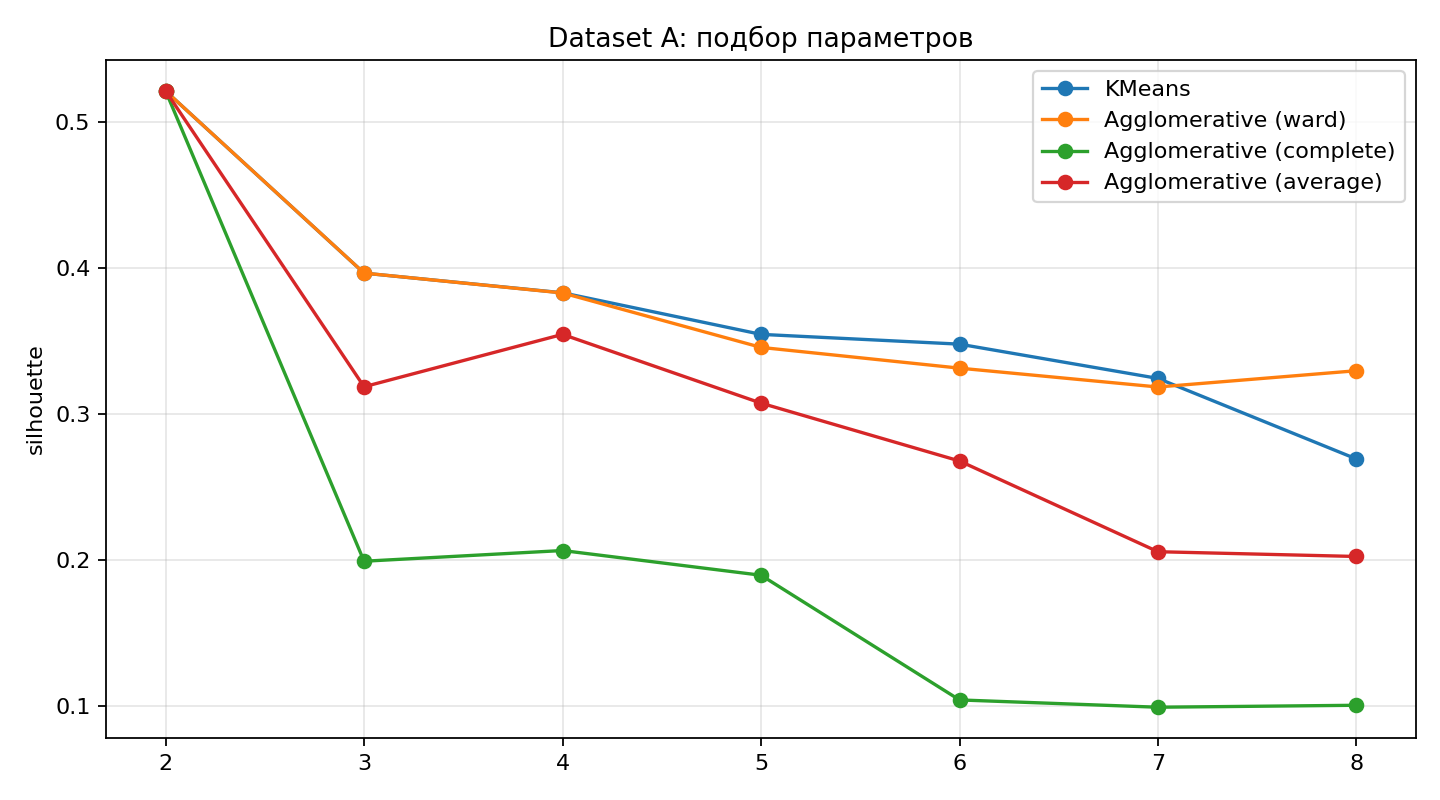

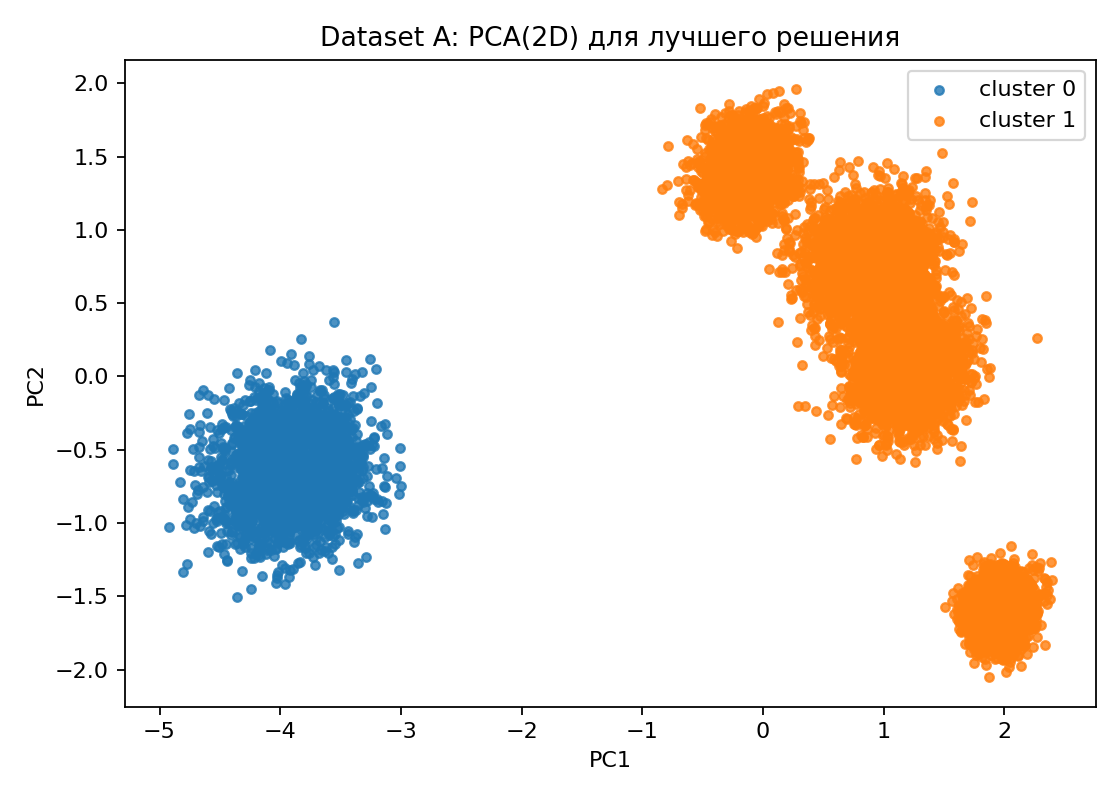


=== Dataset B ===
Best config: KMeans {'k': 2, 'n_init': 20, 'random_state': 42}


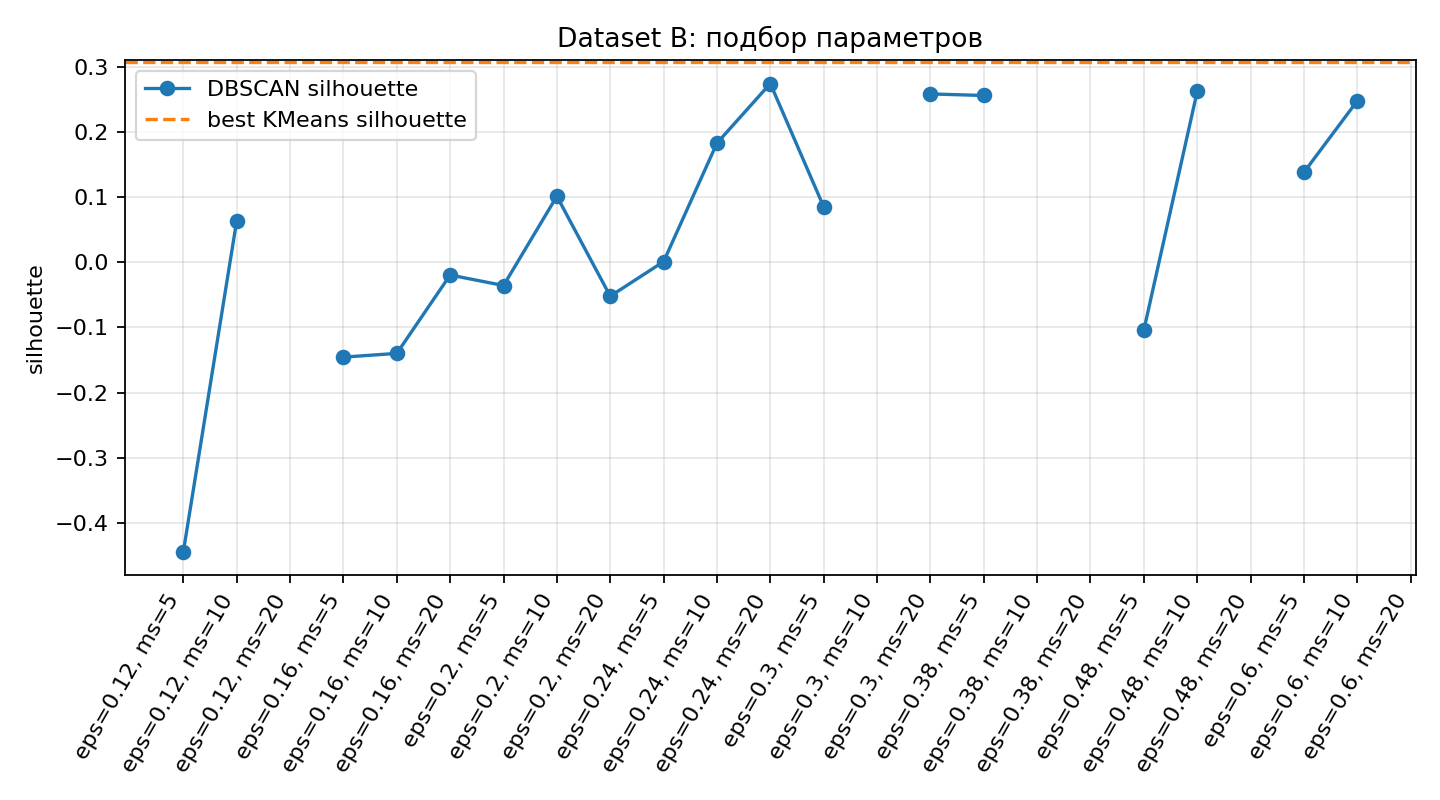

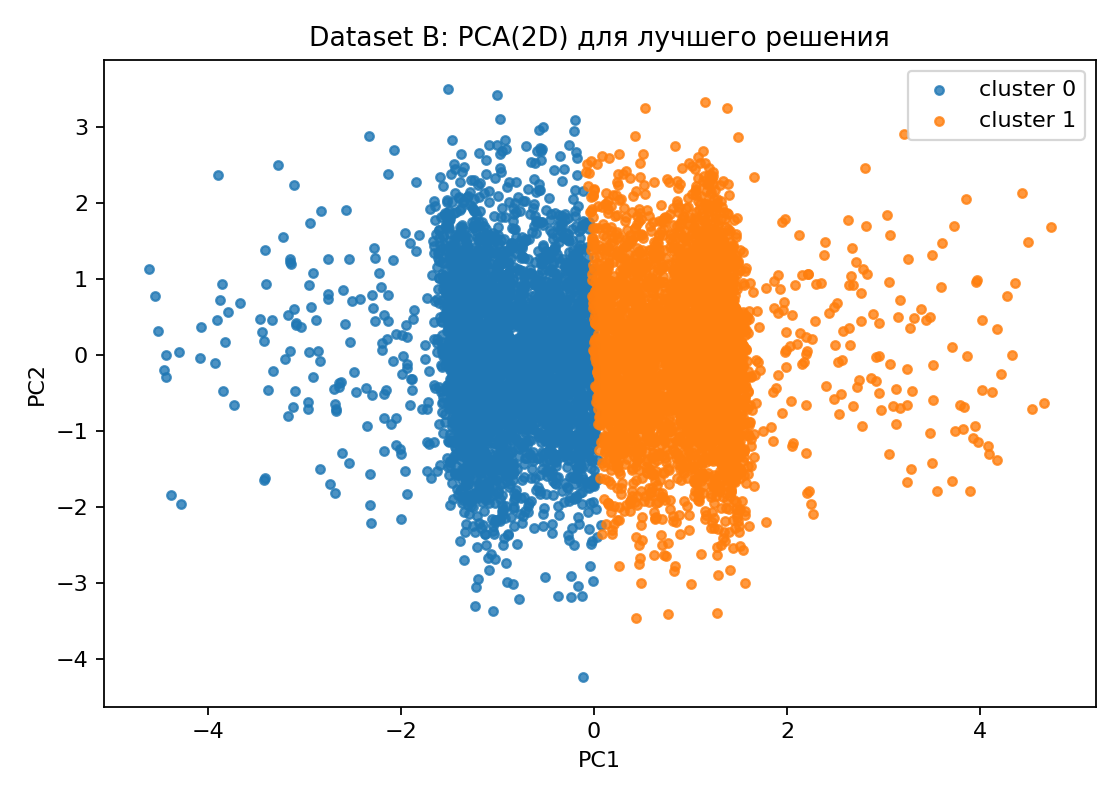


=== Dataset C ===
Best config: KMeans {'k': 5, 'n_init': 20, 'random_state': 42}


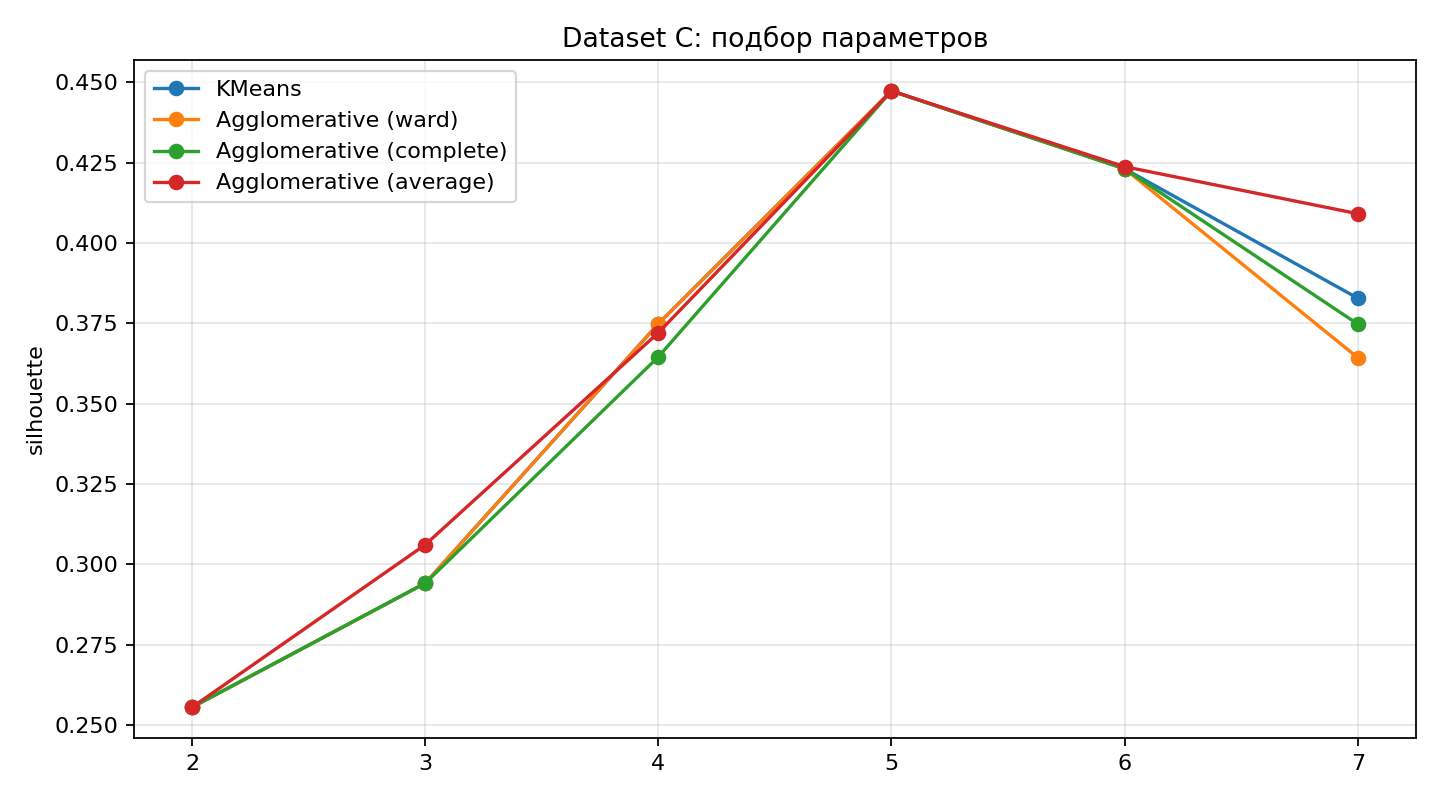

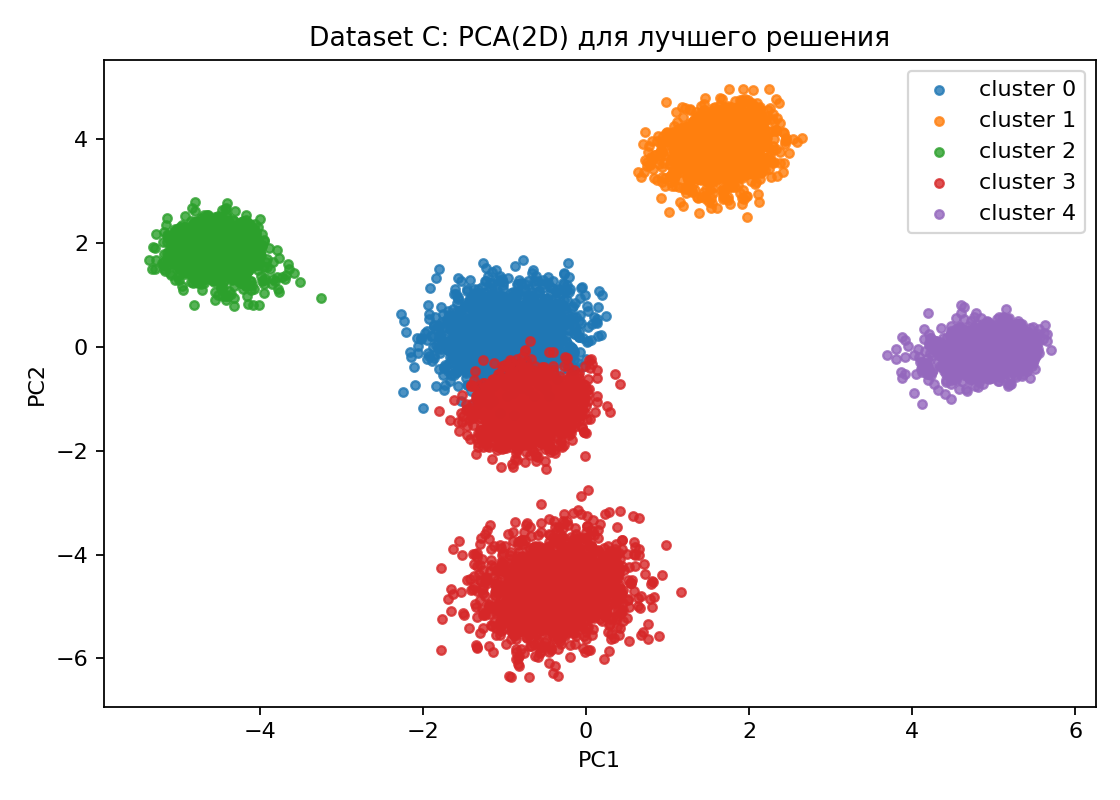

In [7]:
artifacts_dir = Path('artifacts')
for dataset_key, best in result['best_configs'].items():
    print(f"\n=== {DATASETS[dataset_key]['title']} ===")
    print('Best config:', best['algorithm'], best['params'])
    display(Image(filename=str(artifacts_dir / 'figures' / best['search_figure'])))
    display(Image(filename=str(artifacts_dir / 'figures' / best['pca_figure'])))

## Краткие выводы по датасетам

In [8]:
for dataset_key, best in result['best_configs'].items():
    interpretation = result['interpretations'][dataset_key]
    print(f"\n{DATASETS[dataset_key]['title']}")
    print('algorithm:', best['algorithm'])
    print('params:', best['params'])
    print('metrics:', best['silhouette'], best['davies_bouldin'], best['calinski_harabasz'])
    print(json.dumps(interpretation, ensure_ascii=False, indent=2))


Dataset A
algorithm: KMeans
params: {'k': 2, 'n_init': 20, 'random_state': 42}
metrics: 0.52164 0.68533 11786.954623
{
  "numeric_means": {
    "0": {
      "f04": -102.674,
      "f02": 60.096,
      "f06": 29.256
    },
    "1": {
      "f04": 15.313,
      "f02": 8.861,
      "f06": -6.11
    }
  },
  "categorical_modes": {}
}

Dataset B
algorithm: KMeans
params: {'k': 2, 'n_init': 20, 'random_state': 42}
metrics: 0.306861 1.323472 3573.393333
{
  "numeric_means": {
    "0": {
      "x1": 1.132,
      "x2": -0.204,
      "z_noise": 0.227
    },
    "1": {
      "x1": -0.18,
      "x2": 0.69,
      "z_noise": -0.007
    }
  },
  "categorical_modes": {}
}

Dataset C
algorithm: KMeans
params: {'k': 5, 'n_init': 20, 'random_state': 42}
metrics: 0.447369 0.975904 5087.688517
{
  "numeric_means": {
    "0": {
      "n21": 26.455,
      "n09": 13.338,
      "n03": -3.605
    },
    "1": {
      "n21": -41.256,
      "n09": -11.593,
      "n03": 30.637
    },
    "2": {
      "n21": 20.564